In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
from sklearn.datasets import fetch_openml

speed_dating = fetch_openml(data_id=40536, as_frame=True)
df = speed_dating.frame

print("Dataset loaded successfully.")
print(f"Number of instances (rows): {df.shape[0]}")
print(f"Number of attributes (columns): {df.shape[1]}")

Dataset loaded successfully.
Number of instances (rows): 8378
Number of attributes (columns): 121


In [3]:
df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,importance_same_race,importance_same_religion,d_importance_same_race,d_importance_same_religion,field,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,d_pref_o_attractive,d_pref_o_sincere,d_pref_o_intelligence,d_pref_o_funny,d_pref_o_ambitious,d_pref_o_shared_interests,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,d_attractive_o,d_sinsere_o,d_intelligence_o,d_funny_o,d_ambitous_o,d_shared_interests_o,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,d_attractive_important,d_sincere_important,d_intellicence_important,d_funny_important,d_ambtition_important,d_shared_interests_important,attractive,sincere,intelligence,funny,ambition,d_attractive,d_sincere,d_intelligence,d_funny,d_ambition,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,d_attractive_partner,d_sincere_partner,d_intelligence_partner,d_funny_partner,d_ambition_partner,d_shared_interests_partner,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,d_sports,d_tvsports,d_exercise,d_dining,d_museums,d_art,d_hiking,d_gaming,d_clubbing,d_reading,d_tv,d_theater,d_movies,d_concerts,d_music,d_shopping,d_yoga,interests_correlate,d_interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,35.0,20.0,20.0,20.0,0.0,5.0,[21-100],[16-20],[16-20],[16-20],[0-15],[0-15],6.0,8.0,8.0,8.0,8.0,6.0,[6-8],[6-8],[6-8],[6-8],[6-8],[6-8],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],6.0,9.0,7.0,7.0,6.0,5.0,[6-8],[9-10],[6-8],[6-8],[6-8],[0-5],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.14,[0-0.33],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,60.0,0.0,0.0,40.0,0.0,0.0,[21-100],[0-15],[0-15],[21-100],[0-15],[0-15],7.0,8.0,10.0,7.0,7.0,5.0,[6-8],[6-8],[9-10],[6-8],[6-8],[0-5],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],7.0,8.0,7.0,8.0,5.0,6.0,[6-8],[6-8],[6-8],[6-8],[0-5],[6-8],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.54,[0.33-1],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,2.0,4.0,[2-5],[2-5],Law,19.0,18.0,19.0,18.0,14.0,12.0,[16-20],[16-20],[16-20],[16-20],[0-15],[0-15],10.0,10.0,10.0,10.0,10.0,10.0,[9-10],[9-10],[9-10],[9-10],[9-10],[9-10],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],5.0,8.0,9.0,8.0,5.0,7.0,[0-5],[6-8],[9-10],[6-8],[0-5],[6-8],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.16,[0-0.33],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,30.0,5.0,15.0,40.0,5.0,5.0,[21-100],[0-15],[0-15],[21-100],[0-15],[0-15],7.0

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 121 entries, has_null to match
dtypes: category(62), float64(57), int64(2)
memory usage: 4.3 MB


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Number of columns with missing values: {len(missing)}")
print(f"Total missing values: {df.isnull().sum().sum()}")
print()
print(missing)

Number of columns with missing values: 60
Total missing values: 18372

expected_num_interested_in_me    6578
expected_num_matches             1173
shared_interests_o               1076
shared_interests_partner         1067
ambitous_o                        722
ambition_partner                  712
met                               375
funny_o                           360
funny_partner                     350
guess_prob_liked                  309
intelligence_o                    306
intelligence_partner              296
sinsere_o                         287
sincere_partner                   277
like                              240
attractive_o                      212
attractive_partner                202
interests_correlate               158
pref_o_shared_interests           129
shared_interests_important        121
pref_o_ambitious                  107
sincere                           105
ambition                          105
funny                             105
intelligence     

In [6]:
d_columns = [col for col in df.columns if col.startswith('d_') and col != 'd_age']
print(f"Number of discretized ('d_') columns: {len(d_columns)}")

Number of discretized ('d_') columns: 55


In [7]:
non_d_columns = [col for col in df.columns if not col.startswith('d_')]
print(f"Number of non-'d_' columns: {len(non_d_columns)}")

Number of non-'d_' columns: 65


In [8]:
df.to_csv('../data/raw/speed_dating_raw.csv', index=False)
print("Raw data saved to data/raw/speed_dating_raw.csv")

Raw data saved to data/raw/speed_dating_raw.csv


In [9]:
meta = df[['wave', 'match']].copy()

columns_to_drop = ['has_null', 'expected_num_interested_in_me', 'wave'] + d_columns
df_clean = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns.")
print(f"Remaining shape: {df_clean.shape}")

Dropped 58 columns.
Remaining shape: (8378, 63)


In [10]:
IMPORTANCE = ['attractive_important','sincere_important','intellicence_important',
              'funny_important','ambtition_important','shared_interests_important']
PREF_O = ['pref_o_attractive','pref_o_sincere','pref_o_intelligence',
          'pref_o_funny','pref_o_ambitious','pref_o_shared_interests']
SELF = ['attractive','sincere','intelligence','funny','ambition']
PARTNER = ['attractive_partner','sincere_partner','intelligence_partner',
           'funny_partner','ambition_partner','shared_interests_partner']
BY_PARTNER = ['attractive_o','sinsere_o','intelligence_o','funny_o',
              'ambitous_o','shared_interests_o']
INTERESTS = ['sports','tvsports','exercise','dining','museums','art','hiking','gaming',
             'clubbing','reading','tv','theater','movies','concerts','music','shopping','yoga']
RATING_1_10 = SELF + PARTNER + BY_PARTNER + ['like','guess_prob_liked',
                                             'expected_happy_with_sd_people']

s = df_clean[IMPORTANCE].sum(axis=1)
full = df_clean[IMPORTANCE].notna().all(axis=1)
print('Weight sums != 100:', int((((s-100).abs() > 1) & full).sum()), '| max sum:', s[full].max())
print('Interests out of [1,10]:', int(((df_clean[INTERESTS]>10)|(df_clean[INTERESTS]<1)).sum().sum()))
print('Ratings out of [1,10]:', int(((df_clean[RATING_1_10]>10)|(df_clean[RATING_1_10]<1)).sum().sum()))
print('met not in {0,1}:', int(((~df_clean['met'].isin([0,1])) & df_clean['met'].notna()).sum()))

q1, q3 = df_clean['age'].quantile([.25,.75])
iqr = q3 - q1
print('age outliers (IQR):', int(((df_clean['age'] < q1-1.5*iqr) | (df_clean['age'] > q3+1.5*iqr)).sum()))

Weight sums != 100: 144 | max sum: 148.0
Interests out of [1,10]: 350
Ratings out of [1,10]: 259
met not in {0,1}: 8
age outliers (IQR): 173


In [11]:
df_clean['met'] = (df_clean['met'] > 0).astype(float).where(df_clean['met'].notna())

df_clean[RATING_1_10] = df_clean[RATING_1_10].clip(1, 10)
df_clean[INTERESTS] = df_clean[INTERESTS].clip(1, 10)

for block in (IMPORTANCE, PREF_O):
    complete = df_clean[block].notna().all(axis=1)
    valid = complete & (df_clean[block].sum(axis=1) > 0)
    df_clean.loc[valid, block] = df_clean.loc[valid, block].div(
        df_clean.loc[valid, block].sum(axis=1), axis=0) * 100

print("Domain corrections applied.")
print('Weight sums != 100 (after):', int((((df_clean[IMPORTANCE].sum(axis=1)-100).abs() > 1) 
                                          & df_clean[IMPORTANCE].notna().all(axis=1)).sum()))
print('Interests out of range (after):', int(((df_clean[INTERESTS]>10)|(df_clean[INTERESTS]<1)).sum().sum()))
print('Ratings out of range (after):', int(((df_clean[RATING_1_10]>10)|(df_clean[RATING_1_10]<1)).sum().sum()))
print('met not in {0,1} (after):', int(((~df_clean['met'].isin([0,1])) & df_clean['met'].notna()).sum()))

Domain corrections applied.
Weight sums != 100 (after): 0
Interests out of range (after): 0
Ratings out of range (after): 0
met not in {0,1} (after): 0


In [12]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print()
print("Categorical:", categorical_cols)

Numeric columns: 57
Categorical columns: 6

Categorical: ['gender', 'race', 'race_o', 'samerace', 'field', 'match']


In [13]:
for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")
    print(f"  {df_clean[col].unique()[:10]}")
    print()

gender: 2 unique values
  ['female', 'male']
Categories (2, str): ['female', 'male']

race: 5 unique values
  ['Asian/Pacific Islander/Asian-American', 'European/Caucasian-American', 'Other', 'Latino/Hispanic American', 'Black/African American', NaN]
Categories (5, str): ['Asian/Pacific Islander/Asian-American', 'Black/African American', 'Latino/Hispanic American', 'European/Caucasian-American', 'Other']

race_o: 5 unique values
  ['European/Caucasian-American', 'Asian/Pacific Islander/Asian-American', 'Latino/Hispanic American', 'Other', 'Black/African American', NaN]
Categories (5, str): ['Asian/Pacific Islander/Asian-American', 'Black/African American', 'Latino/Hispanic American', 'European/Caucasian-American', 'Other']

samerace: 2 unique values
  ['0', '1']
Categories (2, str): ['0', '1']

field: 259 unique values
  ['Law', 'law', 'Economics', 'Masters in Public Administration', 'Masters of Social Work&Education', 'Finance', 'Business', 'political science', 'money', 'Operations Re

In [14]:
counts = df_clean['field'].value_counts()
print(f"Total unique values: {len(counts)}")
print(f"Values appearing only once: {(counts == 1).sum()}")
print()
print(counts[counts >= 2])

Total unique values: 259
Values appearing only once: 0

field
Business                  521
MBA                       468
Law                       462
Social Work               378
International Affairs     252
                         ... 
biomedical informatics      6
math of finance             6
Stats                       6
marine geophysics           5
theory                      5
Name: count, Length: 259, dtype: int64


In [15]:
pd.set_option('display.max_rows', None)
print(df_clean['field'].value_counts())
pd.set_option('display.max_rows', 60)

field
Business                                                    521
MBA                                                         468
Law                                                         462
Social Work                                                 378
International Affairs                                       252
Electrical Engineering                                      164
Psychology                                                  139
law                                                         123
Finance                                                     113
business                                                    110
Mathematics                                                  95
Film                                                         92
Sociology                                                    88
Biology                                                      85
Engineering                                                  81
Business [MBA]                    

In [16]:
def group_field(value):
    if pd.isna(value):
        return 'Unknown'
    v = str(value).lower()
    
    if any(k in v for k in ['business', 'mba', 'finance', 'financ', 'economic', 'econs', 'marketing', 'consulting', 'money', 'management', 'real estate', 'qmss', 'quantitative methods']):
        return 'Business/Finance'
    if 'law' in v or 'legal' in v or 'intellectual property' in v or 'human rights' in v:
        return 'Law'
    if any(k in v for k in ['engineer', 'computer', 'operations research', 'seas', 'climate', 'environ']):
        return 'Engineering/Tech'
    if any(k in v for k in ['medicine', 'medical', 'premed', 'health', 'nutrition', 'nutritiron', 'epidemiology', 'speech', 'physiology', 'informatics', 'biomedic']):
        return 'Medicine/Health'
    if any(k in v for k in ['biology', 'biolog', 'chemistry', 'physics', 'genetic', 'neuro', 'biochem', 'microbio', 'molecular', 'ecology', 'cell', 'biotech', 'conservation', 'geophysics', 'earth']):
        return 'Natural Sciences'
    if any(k in v for k in ['math', 'statistic', 'stats', 'theory']):
        return 'Math/Statistics'
    if any(k in v for k in ['education', 'teaching', 'tesol', 'giftedness', 'literacy', 'instructional', 'curriculum']):
        return 'Education'
    if any(k in v for k in ['journalism', 'communication', 'media']):
        return 'Journalism/Communications'
    if any(k in v for k in ['psycholog', 'sociolog', 'political', 'anthropolog', 'international affairs', 'international relations', 'international politics', 'international', 'public admin', 'public policy', 'sipa', 'mia', 'social work', 'urban planning', 'human', 'religion', 'philosophy', 'african-american', 'american studies']):
        return 'Social Sciences'
    if any(k in v for k in ['film', 'theat', 'acting', 'mfa', 'writing', 'history', 'classics', 'english', 'literature', 'lit', 'art', 'music', 'creative', 'nonfiction', 'poetry', 'french', 'polish', 'chinese', 'japanese', 'german', 'comparative', 'fine arts', 'museum', 'architecture', 'arts admin', 'fundraising']):
        return 'Arts/Humanities'
    return 'Other'

df_clean['field'] = df_clean['field'].astype('object').apply(group_field)

print(df_clean['field'].value_counts(dropna=False))

field
Business/Finance             2012
Social Sciences              1816
Natural Sciences              813
Engineering/Tech              756
Law                           685
Arts/Humanities               673
Education                     652
Medicine/Health               497
Math/Statistics               210
Other                         128
Journalism/Communications      73
Unknown                        63
Name: count, dtype: int64


In [17]:
df_clean['samerace'] = df_clean['samerace'].astype(int)
df_clean['match'] = df_clean['match'].astype(int)

print("samerace dtype:", df_clean['samerace'].dtype)
print("match dtype:", df_clean['match'].dtype)
print()
print("match distribution:")
print(df_clean['match'].value_counts())

samerace dtype: int64
match dtype: int64

match distribution:
match
0    6998
1    1380
Name: count, dtype: int64


In [18]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['category', 'object', 'string']).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print()
print("Categorical:", categorical_cols)

Numeric columns: 59
Categorical columns: 4

Categorical: ['gender', 'race', 'race_o', 'field']


In [19]:
partner_rating_cols = ['attractive_o', 'sincere_o', 'intelligence_o', 'funny_o', 
                       'ambitous_o', 'shared_interests_o',
                       'attractive_partner', 'sincere_partner', 'intelligence_partner',
                       'funny_partner', 'ambition_partner', 'shared_interests_partner']

partner_rating_cols = [c for c in partner_rating_cols if c in df_clean.columns]

overall_match_rate = df_clean['match'].mean()
print(f"Overall match rate: {overall_match_rate:.3f}")
print()

for col in partner_rating_cols:
    missing_mask = df_clean[col].isnull()
    if missing_mask.sum() == 0:
        continue
    match_when_missing = df_clean.loc[missing_mask, 'match'].mean()
    match_when_present = df_clean.loc[~missing_mask, 'match'].mean()
    print(f"{col}:")
    print(f"  missing count: {missing_mask.sum()}")
    print(f"  match rate when MISSING:  {match_when_missing:.3f}")
    print(f"  match rate when PRESENT:  {match_when_present:.3f}")
    print()

Overall match rate: 0.165

attractive_o:
  missing count: 212
  match rate when MISSING:  0.014
  match rate when PRESENT:  0.169

intelligence_o:
  missing count: 306
  match rate when MISSING:  0.033
  match rate when PRESENT:  0.170

funny_o:
  missing count: 360
  match rate when MISSING:  0.042
  match rate when PRESENT:  0.170

ambitous_o:
  missing count: 722
  match rate when MISSING:  0.108
  match rate when PRESENT:  0.170

shared_interests_o:
  missing count: 1076
  match rate when MISSING:  0.112
  match rate when PRESENT:  0.173

attractive_partner:
  missing count: 202
  match rate when MISSING:  0.015
  match rate when PRESENT:  0.168

sincere_partner:
  missing count: 277
  match rate when MISSING:  0.036
  match rate when PRESENT:  0.169

intelligence_partner:
  missing count: 296
  match rate when MISSING:  0.034
  match rate when PRESENT:  0.170

funny_partner:
  missing count: 350
  match rate when MISSING:  0.043
  match rate when PRESENT:  0.170

ambition_partner:

In [20]:
for c in ['race', 'race_o']:
    df_clean[c] = df_clean[c].astype('object').fillna('Unknown')

print("Categorical NaNs replaced with 'Unknown'.")
print(f"Missing values in categorical columns: {df_clean[categorical_cols].isnull().sum().sum()}")
print()
for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")

Categorical NaNs replaced with 'Unknown'.
Missing values in categorical columns: 0

gender: 2 unique values
race: 6 unique values
race_o: 6 unique values
field: 12 unique values


In [21]:
df_clean['gender_male'] = (df_clean['gender'] == 'male').astype(int)
df_clean = df_clean.drop(columns=['gender'])

df_encoded = pd.get_dummies(df_clean, columns=['race', 'race_o', 'field'], drop_first=False)

bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Encoding done.")
print(f"Shape: {df_encoded.shape}")
print()
print("New columns:")
print([c for c in df_encoded.columns if c.startswith(('race_', 'field_', 'gender_'))])

Encoding done.
Shape: (8378, 84)

New columns:
['gender_male', 'race_Asian/Pacific Islander/Asian-American', 'race_Black/African American', 'race_European/Caucasian-American', 'race_Latino/Hispanic American', 'race_Other', 'race_Unknown', 'race_o_Asian/Pacific Islander/Asian-American', 'race_o_Black/African American', 'race_o_European/Caucasian-American', 'race_o_Latino/Hispanic American', 'race_o_Other', 'race_o_Unknown', 'field_Arts/Humanities', 'field_Business/Finance', 'field_Education', 'field_Engineering/Tech', 'field_Journalism/Communications', 'field_Law', 'field_Math/Statistics', 'field_Medicine/Health', 'field_Natural Sciences', 'field_Other', 'field_Social Sciences', 'field_Unknown']


In [22]:
y_match = df_encoded['match'].copy()
X = df_encoded.drop(columns=['match'])

BLOCKS = {
    'gender':   ['gender_male'],
    'samerace': ['samerace'],
    'race':     [c for c in X.columns if c.startswith('race_') and not c.startswith('race_o_')],
    'race_o':   [c for c in X.columns if c.startswith('race_o_')],
    'field':    [c for c in X.columns if c.startswith('field_')],
}

CAT_COLS = [c for block in BLOCKS.values() for c in block]
CONT_COLS = [c for c in X.columns if c not in CAT_COLS]

print(f"Continuous: {len(CONT_COLS)} | Categorical: {len(CAT_COLS)} in {len(BLOCKS)} blocks")
print()
for name, cols in BLOCKS.items():
    print(f"{name:<10} {len(cols)} columns")

Continuous: 57 | Categorical: 26 in 5 blocks

gender     1 columns
samerace   1 columns
race       6 columns
race_o     6 columns
field      12 columns


In [23]:
from sklearn.preprocessing import StandardScaler

W_CAT = 1.0

scaler = StandardScaler()
X_scaled = X.copy().astype(float)
X_scaled[CONT_COLS] = scaler.fit_transform(X[CONT_COLS])

block_scales = {}
for name, cols in BLOCKS.items():
    total_var = X[cols].astype(float).var(ddof=0).sum()
    factor = W_CAT / np.sqrt(total_var)
    block_scales[name] = float(factor)
    X_scaled[cols] = X[cols].astype(float) * factor

print("Scaling done.")
print(f"Missing values still present: {X_scaled.isnull().sum().sum()}")
print()
for name, cols in BLOCKS.items():
    print(f"{name:<10} variance contribution: {X_scaled[cols].var(ddof=0).sum():.3f}")
print()
cat_var = sum(X_scaled[c].var(ddof=0) for c in CAT_COLS)
cont_var = sum(X_scaled[c].var(ddof=0) for c in CONT_COLS)
print(f"Categorical share of total variance: {100*cat_var/(cat_var+cont_var):.1f}%")

Scaling done.
Missing values still present: 11595

gender     variance contribution: 1.000
samerace   variance contribution: 1.000
race       variance contribution: 1.000
race_o     variance contribution: 1.000
field      variance contribution: 1.000

Categorical share of total variance: 8.1%


In [24]:
person_key = ['age', 'gender_male', 'race_Asian/Pacific Islander/Asian-American',
              'race_Black/African American', 'race_European/Caucasian-American',
              'race_Latino/Hispanic American', 'race_Other', 'race_Unknown']
person_key += [c for c in X.columns if c.startswith('field_')]
person_key += ['attractive_important','sincere_important','intellicence_important',
               'funny_important','ambtition_important','shared_interests_important']

key_df = X[person_key].copy()
key_df['wave'] = meta['wave'].values

person_id = key_df.apply(lambda row: '|'.join(map(str, row.values)), axis=1).factorize()[0]

counts = pd.Series(person_id).value_counts()
print(f"Reconstructed persons: {len(counts)}")
print(f"Rows per person: min {counts.min()}, median {int(counts.median())}, max {counts.max()}")

Reconstructed persons: 549
Rows per person: min 5, median 16, max 22


In [25]:
PERSON_LEVEL = SELF + INTERESTS + IMPORTANCE + PREF_O + [
    'age', 'importance_same_race', 'importance_same_religion',
    'expected_happy_with_sd_people', 'expected_num_matches'
]
PERSON_LEVEL = [c for c in PERSON_LEVEL if c in X_scaled.columns]

missing_before = X_scaled[PERSON_LEVEL].isnull().sum().sum()

X_scaled['_pid'] = person_id
X_scaled[PERSON_LEVEL] = X_scaled.groupby('_pid')[PERSON_LEVEL].transform(
    lambda s: s.fillna(s.median())
)
X_scaled = X_scaled.drop(columns=['_pid'])

missing_after = X_scaled[PERSON_LEVEL].isnull().sum().sum()

print(f"Person-level missing BEFORE: {missing_before}")
print(f"Person-level missing AFTER:  {missing_after}")
print(f"Filled from same person:     {missing_before - missing_after}")
print()
print(f"Total missing remaining (all columns): {X_scaled.isnull().sum().sum()}")

Person-level missing BEFORE: 4542
Person-level missing AFTER:  3931
Filled from same person:     611

Total missing remaining (all columns): 10984


In [26]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = pd.DataFrame(
    knn_imputer.fit_transform(X_scaled),
    columns=X_scaled.columns,
    index=X_scaled.index
)

print("kNN imputation done.")
print(f"Missing values remaining: {X_imputed.isnull().sum().sum()}")
print(f"Shape: {X_imputed.shape}")

kNN imputation done.
Missing values remaining: 0
Shape: (8378, 83)


In [27]:
print("Final feature matrix:")
print(X_imputed.shape)
print()
X_imputed.head()

Final feature matrix:
(8378, 83)



,age,age_o,d_age,samerace,importance_same_race,importance_same_religion,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,attractive,sincere,intelligence,funny,ambition,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_matches,like,guess_prob_liked,met,gender_male,race_Asian/Pacific Islander/Asian-American,race_Black/African American,race_European/Caucasian-American,race_Latino/Hispanic American,race_Other,race_Unknown,race_o_Asian/Pacific Islander/Asian-American,race_o_Black/African American,race_o_European/Caucasian-American,race_o_Latino/Hispanic American,race_o_Other,race_o_Unknown,field_Arts/Humanities,field_Business/Finance,field_Education,field_Engineering/Tech,field_Journalism/Communications,field_Law,field_Math/Statistics,field_Medicine/Health,field_Natural Sciences,field_Other,field_Social Sciences,field_Unknown
0,-1.502553,0.178199,0.394786,0.0000,-0.627226,0.124188,0.994794,0.371384,-0.039488,0.418698,-1.773926,-1.076140,-0.098259,0.474388,0.407118,0.820042,0.681450,0.241920,-0.596313,0.371307,-0.03873,-0.403328,0.722258,0.498238,-0.777197,-0.209564,0.188937,-0.375243,-0.325264,-0.098076,1.050569,-0.238571,0.306758,-0.434334,-0.225791,0.983161,-0.919258,0.725257,0.693069,-2.927749,-2.532537,-0.288134,-1.144246,-0.299563,-0.842281,1.461404,-2.592418,1.228735,1.475701,0.641247,0.907988,-1.233181,-0.184533,-1.461475,0.32405,0.470541,0.371654,-0.216714,0.0,1.277272,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.276342,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.082061,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.502553,-1.224942,-0.693141,0.0000,-0.627226,0.124188,2.982819,-2.471840,-2.984336,3.708481,-1.773926,-1.863242,0.415299,0.474388,1.699393,0.306804,0.123314,-0.225965,-0.596313,0.371307,-0.03873,-0.403328,0.722258,0.498238,-0.777197,-0.209564,0.188937,-0.375243,-0.325264,0.415484,0.474512,-0.238571,0.820025,-0.992478,0.242045,0.983161,-0.919258,0.725257,0.693069,-2.927749,-2.532537,-0.288134,-1.144246,-0.299563,-0.842281,1.461404,-2.592418,1.228735,1.475701,0.641247,0.907988,-1.233181,1.133334,-1.461475,0.32405,0.470541,-0.100945,4.614377,0.0,1.277272,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.276342,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.082061,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.502553,-1.224942,-0.693141,2.0449,-0.627226,0.124188,-0.277542,0.087062,-0.186730,0.089720,0.555231,0.025803,1.955975,1.626332,1.699393,1.846518,1.797724,2.113462,-0.596313,0.371307,-0.03873,-0.403328,0.722258,0.498238,-0.777197,-0.209564,0.188937,-0.375243,-0.325264,-0.611636,0.474512,1.053741,0.820025,-0.992478,0.709881,0.983161,-0.919258,0.725257,0.693069,-2.927749,-2.532537,-0.288134,-1.144246,-0.299563,-0.842281,1.461404,-2.592418,1.228735,1.475701,0.641247,0.907988,-1.233181,-0.118640,-1.461475,0.32405,0.470541,0.563294,4.614377,0.0,1.277272,0.0,0.0,0.0,0.0,0.0,1.276342,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.082061,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.502553,-0.944314,-0.475556,0.0000,-0.627226,0.124188,0.597189,-1.761034,-0.775700,3.708481,-0.942084,-1.076140,0.415299,0.474388,1.053256,0.820042,1.239587,1.177691,-0.596313,0.371307,-0.03873,-0.403328,0.722258,0.498238,-0.777197,-0.209564,0.188937,-0.375243,-0.325264,0.415484,-0.677601,0.407585,0.306758,-0.434334,1.177717,0.983161,-0.919258,0.725257,0.693069,-2.927749,-2.532537,-0.288134,-1.144246,-0.299563,-0.842281,1.461404,-2.592418,1.228735,1.475701,0.641247,0.907988,-1.233181,1.363960,-1.461475,0.32405,0.470541,0.371654,-0.216714,0.0,1.277272,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.276342,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.

In [32]:
person_filled = 611
knn_filled = 10984

print(f"Values recovered from the same person: {person_filled}")
print(f"Values estimated by kNN: {knn_filled}")
print()
print("kNN imputation check (distinct values prove no artificial clumping):")
print()

check_cols = ['attractive_partner', 'funny_o', 'shared_interests_partner', 'like', 'sports']

for col in check_cols:
    mask = X[col].isnull()
    if mask.sum() == 0:
        continue
    vals = X_imputed.loc[mask, col]
    print(f"  {col:<28} {mask.sum():>5} imputed  ->  {vals.nunique():>5} distinct")

print()
print("A median-based imputation would produce a single repeated value per column,")
print("creating artificial clusters of incomplete records.")

Values recovered from the same person: 611
Values estimated by kNN: 10984

kNN imputation check (distinct values prove no artificial clumping):

  attractive_partner             202 imputed  ->    202 distinct
  funny_o                        360 imputed  ->    359 distinct
  shared_interests_partner      1067 imputed  ->   1067 distinct
  like                           240 imputed  ->    238 distinct
  sports                          79 imputed  ->     79 distinct

A median-based imputation would produce a single repeated value per column,
creating artificial clusters of incomplete records.


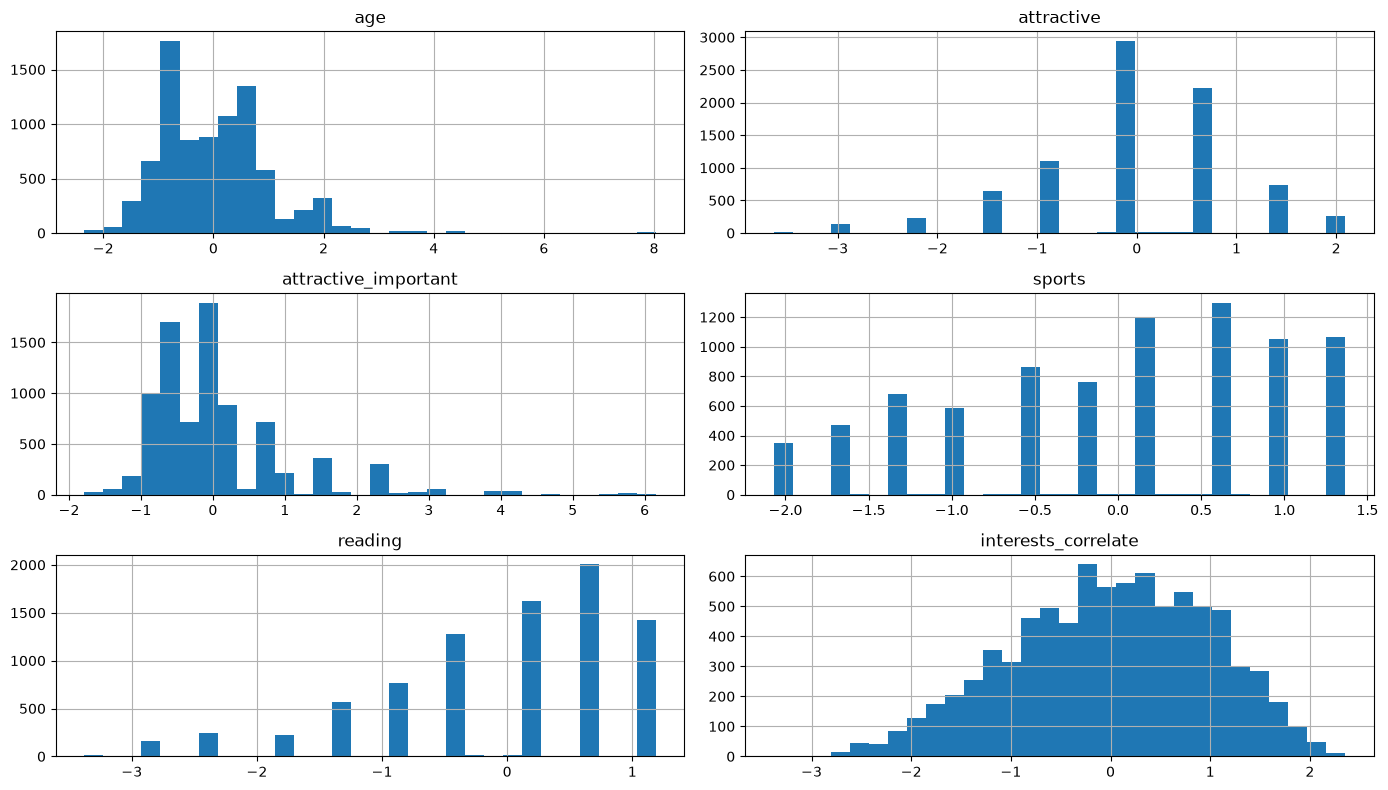

In [29]:
sample_cols = ['age', 'attractive', 'attractive_important', 'sports', 'reading', 'interests_correlate']
X_imputed[sample_cols].hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

In [30]:
X_unscaled = X_imputed.copy()
X_unscaled[CONT_COLS] = scaler.inverse_transform(X_imputed[CONT_COLS])
for name, cols in BLOCKS.items():
    X_unscaled[cols] = X_imputed[cols] / block_scales[name]

X_imputed.to_csv('../data/processed/X_scaled.csv', index=False)
X_unscaled.to_csv('../data/processed/X_unscaled.csv', index=False)
meta.to_csv('../data/processed/metadata.csv', index=False)

joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump(knn_imputer, '../models/knn_imputer.joblib')

with open('../models/preprocessing_config.json', 'w') as f:
    json.dump({
        'W_CAT': W_CAT,
        'block_scales': block_scales,
        'blocks': BLOCKS,
        'continuous': CONT_COLS,
        'random_state': RANDOM_STATE
    }, f, indent=2)

print("Saved:")
print(f"  X_scaled.csv    {X_imputed.shape}   (for clustering)")
print(f"  X_unscaled.csv  {X_unscaled.shape}   (for interpreting centroids)")
print(f"  metadata.csv    {meta.shape}      (wave + match, NOT used in clustering)")
print("  models/scaler.joblib, knn_imputer.joblib, preprocessing_config.json")

Saved:
  X_scaled.csv    (8378, 83)   (for clustering)
  X_unscaled.csv  (8378, 83)   (for interpreting centroids)
  metadata.csv    (8378, 2)      (wave + match, NOT used in clustering)
  models/scaler.joblib, knn_imputer.joblib, preprocessing_config.json
